<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/14_youtube_trending_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/USvideos.csv')

df.head()

Mounted at /content/drive


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [3]:
df.shape

(40949, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [5]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


In [7]:
# Load category JSON and map category_id to readable names
with open('/content/drive/My Drive/Colab Notebooks/EDA/US_category_id.json') as f:
    category_data = json.load(f)

category_map = {int(item['id']): item['snippet']['title'] for item in category_data['items']}

df['category_name'] = df['category_id'].map(category_map)
df[['category_id', 'category_name']].head()

,category_id,category_name
0,22,People & Blogs
1,24,Entertainment
2,23,Comedy
3,24,Entertainment
4,24,Entertainment


**2. Data Cleaning**

In [8]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
description,570
video_id,0
trending_date,0
channel_title,0
title,0
publish_time,0
tags,0
views,0
category_id,0
likes,0


In [9]:
# description sometimes missing - fill with empty string, not critical for this analysis
df['description'] = df['description'].fillna('')

# Drop rows with unmapped category (rare)
df = df.dropna(subset=['category_name'])
df.shape

(40949, 17)

In [10]:
# Check duplicates - a video can trend on multiple days, so check on video_id + trending_date
print("Full duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# For most analyses we'll keep all trending-day rows, but note video_id repeats
print("Unique videos:", df['video_id'].nunique())
print("Total trending-day rows:", len(df))

Full duplicate rows: 48
Unique videos: 6351
Total trending-day rows: 40901


In [11]:
# Convert trending_date (format: YY.DD.MM) and publish_time
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_date'] = df['publish_time'].dt.date
df['publish_date'] = pd.to_datetime(df['publish_date'])

df[['trending_date', 'publish_time', 'publish_date']].head()

,trending_date,publish_time,publish_date
0,2017-11-14,2017-11-13 17:13:01+00:00,2017-11-13
1,2017-11-14,2017-11-13 07:30:00+00:00,2017-11-13
2,2017-11-14,2017-11-12 19:05:24+00:00,2017-11-12
3,2017-11-14,2017-11-13 11:00:04+00:00,2017-11-13
4,2017-11-14,2017-11-12 18:01:41+00:00,2017-11-12


In [12]:
# Calculate days to trend
df['days_to_trend'] = (df['trending_date'] - df['publish_date']).dt.days

# Remove negative values (data errors - trended before published date recorded)
df = df[df['days_to_trend'] >= 0]
df['days_to_trend'].describe()

,days_to_trend
count,40901.000000
mean,16.826850
std,146.099164
min,0.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,4215.000000


In [13]:
# Check ratings_disabled / comments_disabled flags
print(df['ratings_disabled'].value_counts())
print(df['comment_count'].isnull().sum() if 'comment_count' in df.columns else "no comment_count col")

ratings_disabled
False    40732
True       169
Name: count, dtype: int64
0


In [14]:
# Create a clean dataframe for engagement metrics that excludes disabled ratings/comments
df_engaged = df[(df['ratings_disabled'] == False) & (df['comments_disabled'] == False)].copy()
df_engaged.shape


(40206, 19)

In [15]:
# For a single row per video (latest trending appearance), dedupe by video_id
df_unique = df.sort_values('trending_date').drop_duplicates(subset='video_id', keep='last')
df_unique.shape

(6351, 19)

**3. Univariate Analysis**

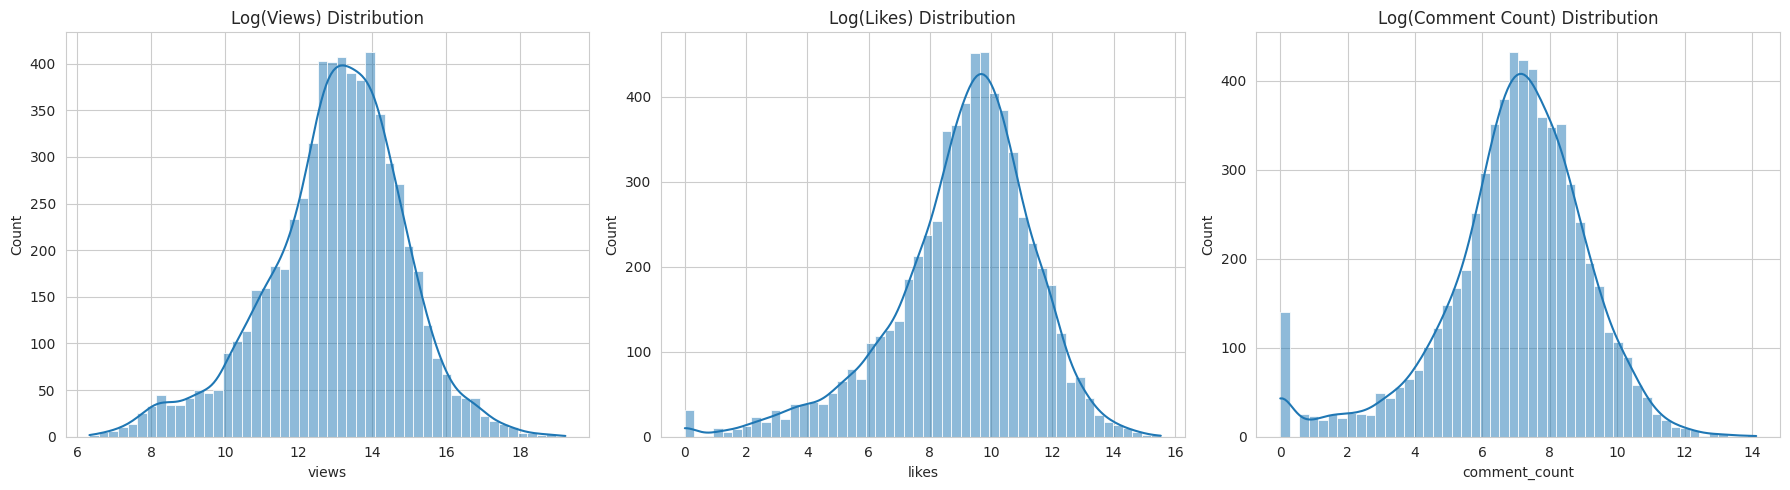

In [16]:
# Views, likes, comment_count distributions (log-transformed)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(np.log1p(df_unique['views']), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Log(Views) Distribution')

sns.histplot(np.log1p(df_unique['likes']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log(Likes) Distribution')

sns.histplot(np.log1p(df_unique['comment_count']), bins=50, kde=True, ax=axes[2])
axes[2].set_title('Log(Comment Count) Distribution')

plt.tight_layout()
plt.show()

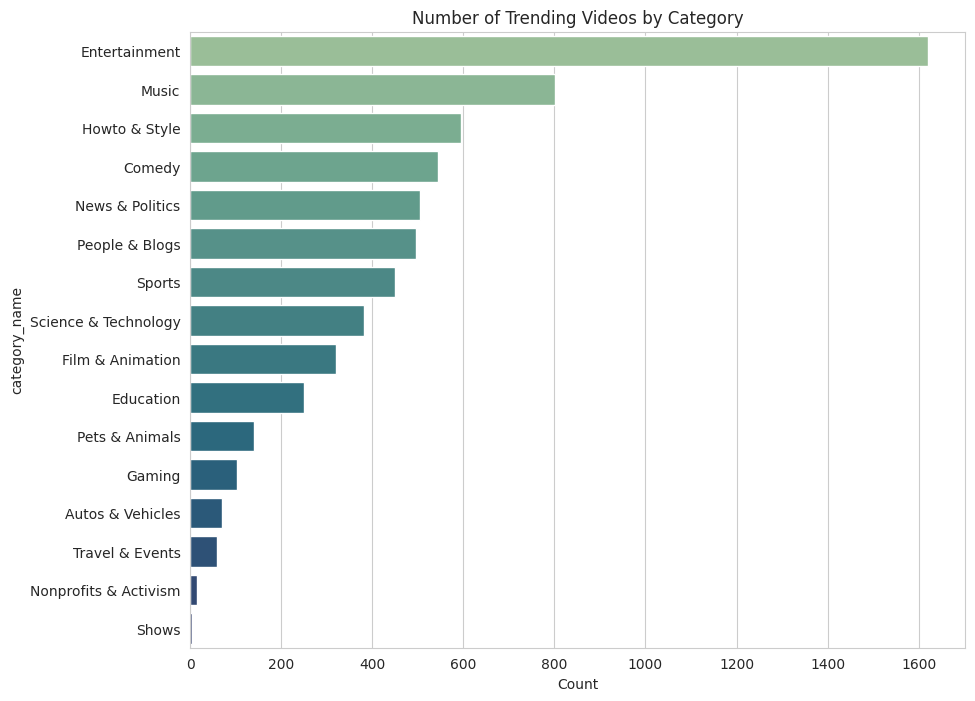

In [17]:
# Distribution by category
category_counts = df_unique['category_name'].value_counts()

plt.figure(figsize=(10,8))
sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, palette='crest', legend=False)
plt.title('Number of Trending Videos by Category')
plt.xlabel('Count')
plt.show()

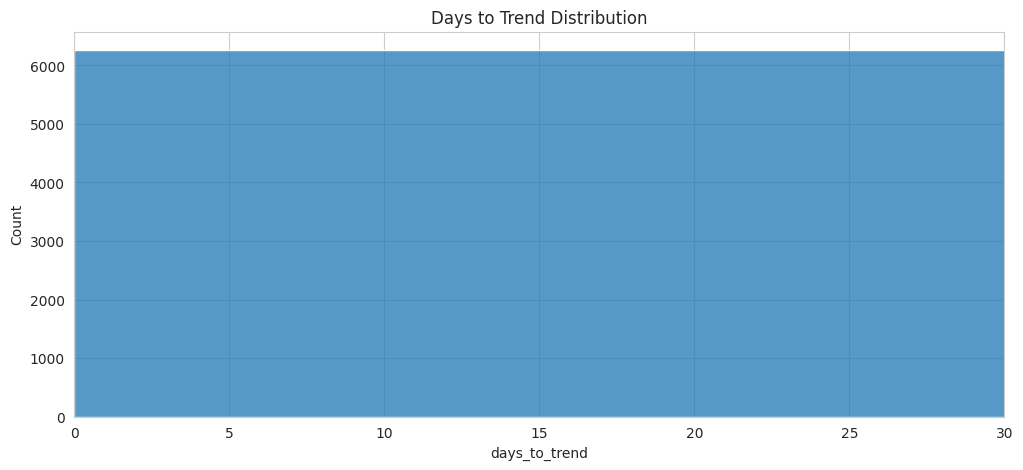

In [18]:
# Days to trend distribution
plt.figure(figsize=(12,5))
sns.histplot(df_unique['days_to_trend'], bins=50)
plt.title('Days to Trend Distribution')
plt.xlim(0, 30)
plt.show()

**4. Engagement Analysis**

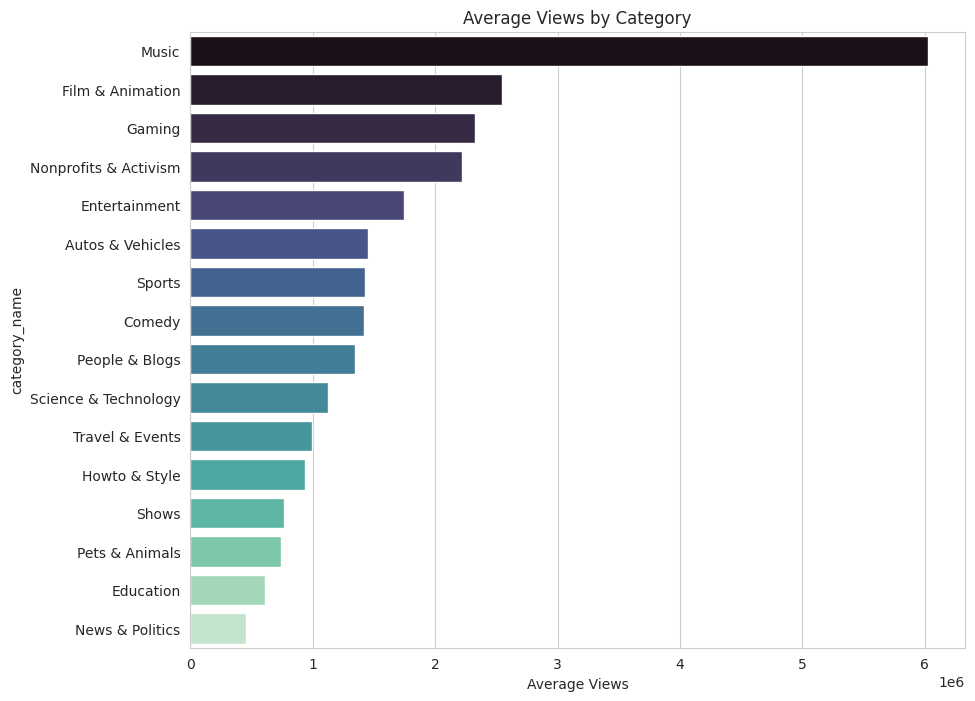

In [19]:
# Average views by category
avg_views_category = df_unique.groupby('category_name')['views'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=avg_views_category.values, y=avg_views_category.index, hue=avg_views_category.index, palette='mako', legend=False)
plt.title('Average Views by Category')
plt.xlabel('Average Views')
plt.show()

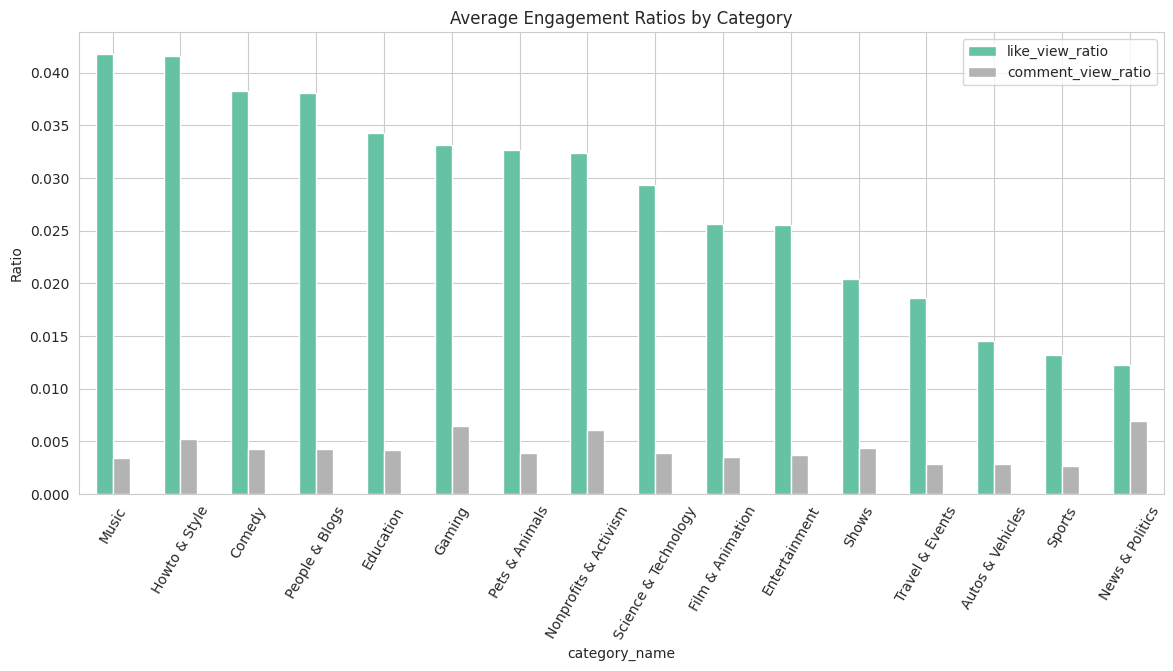

In [20]:
# Like-to-view and comment-to-view ratio by category
df_engaged_unique = df_engaged.sort_values('trending_date').drop_duplicates(subset='video_id', keep='last')
df_engaged_unique['like_view_ratio'] = df_engaged_unique['likes'] / df_engaged_unique['views']
df_engaged_unique['comment_view_ratio'] = df_engaged_unique['comment_count'] / df_engaged_unique['views']

engagement_by_category = df_engaged_unique.groupby('category_name')[['like_view_ratio', 'comment_view_ratio']].mean().sort_values('like_view_ratio', ascending=False)

engagement_by_category.plot(kind='bar', figsize=(14,6), colormap='Set2')
plt.title('Average Engagement Ratios by Category')
plt.ylabel('Ratio')
plt.xticks(rotation=60)
plt.legend(title='')
plt.show()

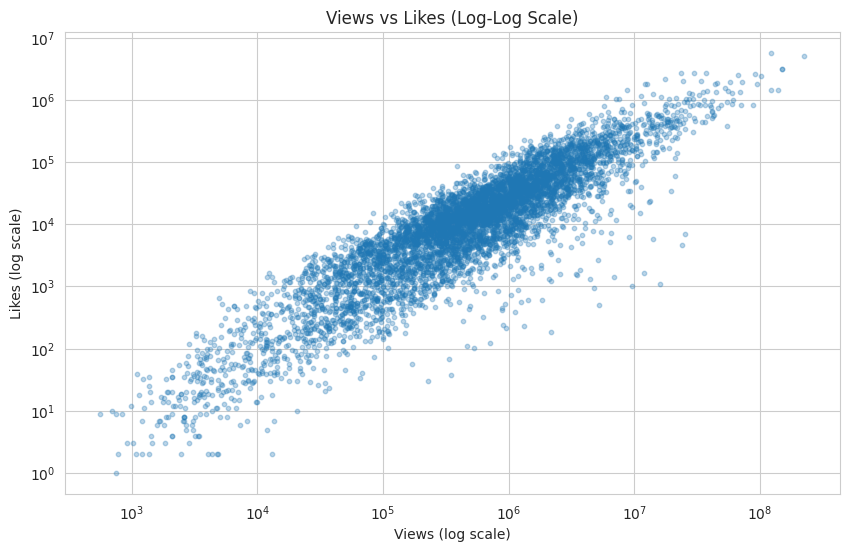

In [21]:
# Views vs Likes (log-log scatter)
plt.figure(figsize=(10,6))
plt.scatter(df_unique['views'], df_unique['likes'], alpha=0.3, s=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Views (log scale)')
plt.ylabel('Likes (log scale)')
plt.title('Views vs Likes (Log-Log Scale)')
plt.show()

In [22]:
# Top 10 most-viewed videos
top_videos = df_unique.nlargest(10, 'views')[['title', 'channel_title', 'category_name', 'views', 'likes']]
top_videos

,title,channel_title,category_name,views,likes
38547,Childish Gambino - This Is America (Official V...,ChildishGambinoVEVO,Music,225211923,5023450
6181,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,149376127,3093544
34708,Ariana Grande - No Tears Left To Cry,ArianaGrandeVevo,Music,148689896,3094021
34888,"Becky G, Natti Natasha - Sin Pijama (Official ...",BeckyGVEVO,Music,139334502,1425496
38273,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,123010920,5613827
34747,The Weeknd - Call Out My Name (Official Video),TheWeekndVEVO,Music,122544931,1427436
2587,"Luis Fonsi, Demi Lovato - Échame La Culpa",LuisFonsiVEVO,Music,102012605,2376636
40869,"Cardi B, Bad Bunny & J Balvin - I Like It [Off...",Cardi B,Music,94254507,1816753
4997,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,91933007,2625661
25947,Maluma - El Préstamo (Official Video),MalumaVEVO,Music,87264467,815369


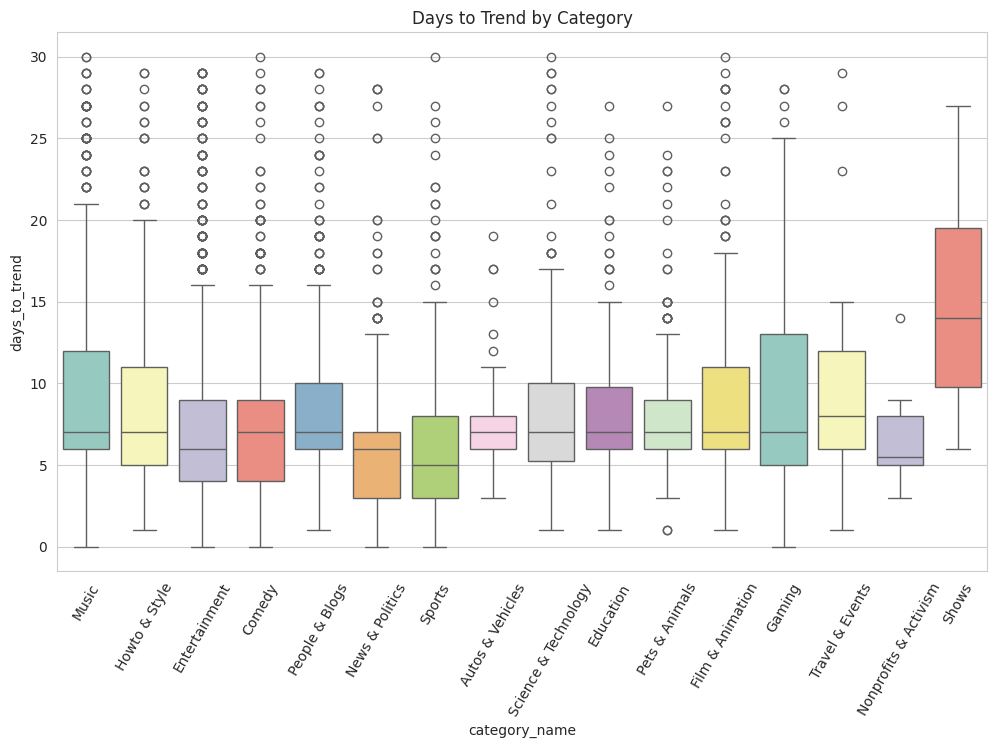

In [23]:
# Days to trend by category
plt.figure(figsize=(12,7))
sns.boxplot(data=df_unique[df_unique['days_to_trend'] <= 30], x='category_name', y='days_to_trend',
            hue='category_name', palette='Set3', legend=False)
plt.title('Days to Trend by Category')
plt.xticks(rotation=60)
plt.show()

**5. Text Analysis**

In [24]:
!pip install nltk -q
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def clean_title(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_unique['clean_title'] = df_unique['title'].apply(clean_title)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


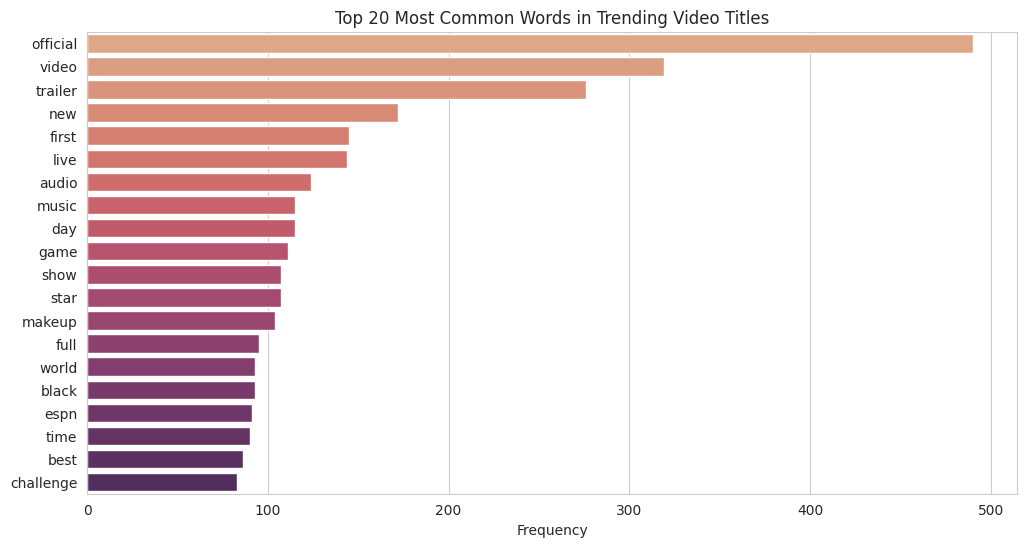

In [25]:
# Most common words in titles
all_title_words = ' '.join(df_unique['clean_title']).split()
filtered_words = [w for w in all_title_words if w not in stop_words and len(w) > 2]

word_freq = Counter(filtered_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='flare', legend=False)
plt.title('Top 20 Most Common Words in Trending Video Titles')
plt.xlabel('Frequency')
plt.show()

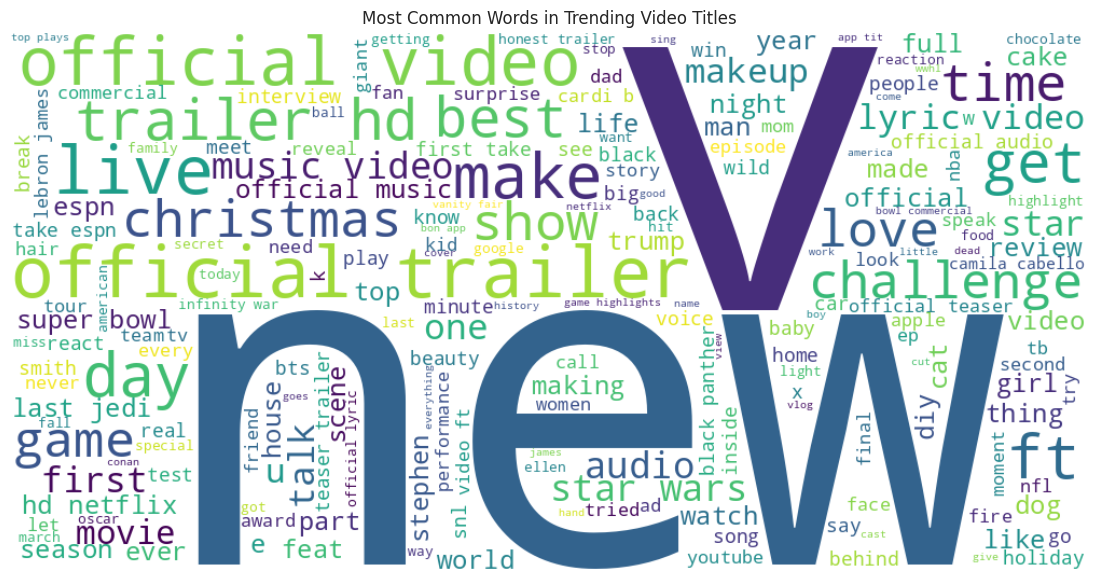

In [26]:
# Word cloud of titles
!pip install wordcloud -q
from wordcloud import WordCloud

title_text = ' '.join(df_unique['clean_title'])
wc = WordCloud(width=1000, height=500, background_color='white',
                stopwords=stop_words, colormap='viridis').generate(title_text)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Trending Video Titles')
plt.show()

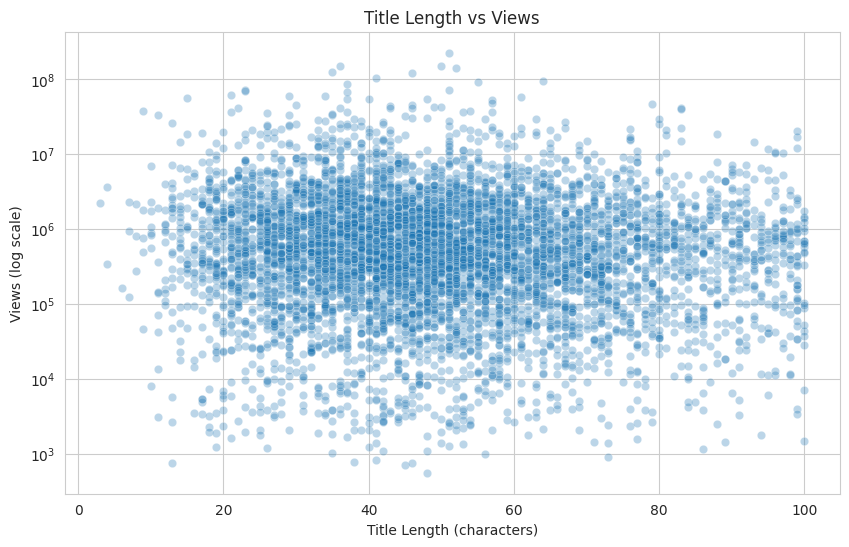

In [27]:
# Title length vs views
df_unique['title_length'] = df_unique['title'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_unique, x='title_length', y='views', alpha=0.3)
plt.yscale('log')
plt.title('Title Length vs Views')
plt.xlabel('Title Length (characters)')
plt.ylabel('Views (log scale)')
plt.show()

**6. Insights Summary**

## Key Insights

- [Category, e.g., Music or Entertainment] dominates trending videos by volume, while [Category] shows the highest average views per video.
- Views and likes show a strong positive log-log correlation, confirming likes scale predictably with reach.
- Engagement ratios (likes/comments per view) vary meaningfully by category — [Category] shows the highest like-to-view ratio despite not having the most raw views, suggesting a more engaged niche audience.
- Most trending videos reach trending status within [X] days of publishing, with a sharp drop-off after that — trending is a fast-moving window.
- Common words in trending titles include [words you observed, e.g., "official," "trailer," "reaction"] — reflecting the dominant content types on the platform.
- Title length shows [little/some] relationship with views — content and topic likely matter far more than title length alone.
- [Add 1-2 more insights specific to what you observed]